# I. Introduction

## *Is the culture of human populations shaped by their social and physical environment?*

**Author** : Léna Rebours

**Date** : January 2025

To what extent is human culture shaped by the social and physical environments in which populations live? This question lies at the heart of cultural and ecological studies, offering insights into how external factors influence values, behaviors, and societal structures. In this analysis, we aim to address this question by focusing on three key ecological variables: GDP per capita, life expectancy, and disease prevalence. By examining the relationships between these variables and cultural traits, we seek to uncover patterns that highlight the influence of economic conditions and health risks on the cultural diversity of human societies.

We might think that the more time, opportunity and money we have ahead of us, the more likely we are to be less inclined to fear failure, and more willing to forgive ourselves, thinking that we have a second chance.


**Predictions :**
- **P1** : Higher GDP per capita is associated with lower levels of fear of failure.
- **P2** : Greater life expectancy decreases the fear of failure.
- **P3** : Higher disease threat increases the fear of failure.
- **P4** : The higher the number of unemployment, the higher th efear of failure


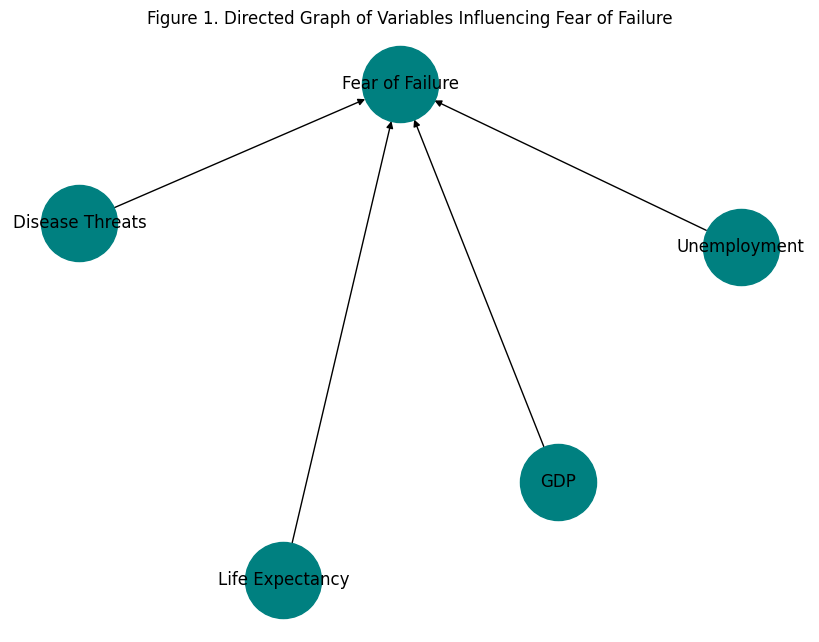

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add nodes
nodes = ['Fear of Failure', 'GDP', 'Life Expectancy', 'Disease Threats', "Unemployment"]
G.add_nodes_from(nodes)

# Add edges (directed connections based on your variables)
edges = [('GDP', 'Fear of Failure'), ('Life Expectancy', 'Fear of Failure'), ('Disease Threats', 'Fear of Failure'), ('Unemployment', 'Fear of Failure')]
G.add_edges_from(edges)

# Draw the graph with a smaller figure size and adjust layout
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

# Draw the graph with smaller nodes and adjusted node size
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='teal', arrows=True, font_size=12)
plt.title("Figure 1. Directed Graph of Variables Influencing Fear of Failure")
plt.show()


# II. Library Import

In [ ]:
import pandas as pd
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import statsmodels.formula.api as smf

# III. Data Import

The Ecology-Culture Dataset (ECD) includes data from 220 countries, covering 9 ecological variables (e.g., rainfall, GDP) and 72 cultural variables (e.g., values, well-being). Data were collected from global organizations and academic sources, with time-series metrics (1950–2020) calculated using advanced statistical methods. This open-access resource enables studies on the links between ecology and culture. More information with this [paper](https://www.nature.com/articles/s41597-022-01738-z)

In [ ]:
uploaded = files.upload()

Saving ECD Data v3.csv to ECD Data v3 (3).csv


In [ ]:
df = pd.read_csv("ECD Data v3.csv", delimiter = ";")
df

,country,year,Country,rain,temp,gdp,mortality,lifeexpectancy,disease,pop_sqr_km,...,democracy,pluralism,govt_functioning,participation,political_culture,CTL_C,soi,region_short,Latitude,Longitude
0,AD,1909,Andorra,661.90580,9.808048,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EURO,42.5,1.5
1,AD,1907,Andorra,886.19270,10.282322,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EURO,42.5,1.5
2,AD,1965,Andorra,868.99010,10.653588,NaN,NaN,NaN,NaN,39.465957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EURO,42.5,1.5
3,AD,1966,Andorra,794.98760,11.246102,NaN,NaN,NaN,NaN,41.802128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EURO,42.5,1.5
4,AD,1930,Andorra,1005.63970,11.161795,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EURO,42.5,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23372,ZW,2016,Zimbabwe,455.13295,22.310167,1464.583529,NaN,60.294,0.474968,35.905239,...,3.16,0.0,2.5,4.44,5.63,30.4,22.66,AFRO,-20.0,30.0
23373,ZW,2017,Zimbabwe,NaN,NaN,1548.170056,NaN,60.812,0.460558,36.433092,...,3.16,0.0,2.5,4.44,5.63,30.4,22.66,AFRO,-20.0,30.0
23374,ZW,2018,Zimbabwe,NaN,NaN,1683.740577,NaN,61.195,0.445579,36.950563,...,3.16,0.0,2.5,4.44,5.63,30.4,22.66,AFRO,-20.0,30.0
23375,ZW,2019,Zimbabwe,NaN,NaN,1463.985910,NaN,NaN,0.432914,37.479445,...,3.16,0.0,2.5,4.44,5.63,30.4,22.66,AFRO,-20.0,30.0


# IV. Data Manipulation

In [ ]:
# Keep only the specified columns
columns_to_keep = ["Country", "gdp", "year", "lifeexpectancy", "disease", "Fear_of_Failure", 'unemployment']
df2 = df[columns_to_keep]
df2

,Country,gdp,year,lifeexpectancy,disease,Fear_of_Failure,unemployment
0,Andorra,NaN,1909,NaN,NaN,NaN,NaN
1,Andorra,NaN,1907,NaN,NaN,NaN,NaN
2,Andorra,NaN,1965,NaN,NaN,NaN,NaN
3,Andorra,NaN,1966,NaN,NaN,NaN,NaN
4,Andorra,NaN,1930,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
23372,Zimbabwe,1464.583529,2016,60.294,0.474968,NaN,NaN
23373,Zimbabwe,1548.170056,2017,60.812,0.460558,NaN,NaN
23374,Zimbabwe,1683.740577,2018,61.195,0.445579,NaN,NaN
23375,Zimbabwe,1463.985910,2019,NaN,0.432914,NaN,NaN


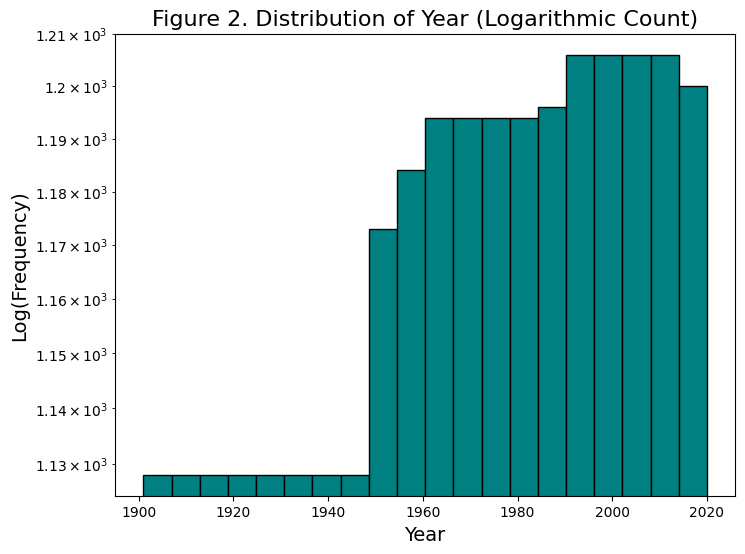

In [ ]:
# Create a histogram with a logarithmic scale for the count (y-axis)
plt.figure(figsize=(8, 6))
plt.hist(df2['year'], bins=20, color='teal', edgecolor='black', log=True)
plt.title('Figure 2. Distribution of Year (Logarithmic Count)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Log(Frequency)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


Now that we have seen the distribution of data for each year, in order to be more significant with our own timeline (2025) and to have enough data, we will focus on the data of the year 2018.

In [ ]:
# Filter rows where the 'year' column equals 2018
df2_filtered = df2[df2['year'] == 2018]

# Display the first few rows of the filtered DataFrame
df2_filtered


,Country,gdp,year,lifeexpectancy,disease,Fear_of_Failure,unemployment
119,Andorra,41793.055260,2018,NaN,0.043337,NaN,NaN
210,United Arab Emirates,43839.356350,2018,77.814,0.043154,59.0,NaN
325,Afghanistan,524.162881,2018,64.486,0.169247,NaN,NaN
449,Antigua and Barbuda,16726.980810,2018,76.885,0.069280,NaN,NaN
527,Albania,5284.380184,2018,78.458,0.025218,47.0,12.3038
...,...,...,...,...,...,...,...
22894,Samoa,4183.408032,2018,73.187,0.087774,NaN,NaN
23014,Yemen,968.159048,2018,66.096,0.120191,NaN,NaN
23134,South Africa,6374.028196,2018,63.857,0.423856,NaN,26.9062
23254,Zambia,1556.334482,2018,63.510,0.461520,NaN,NaN


In [ ]:
# Define the columns to keep and drop rows with missing data in these columns
columns_to_keep = ["Country", "gdp", "year", "lifeexpectancy", "disease", "Fear_of_Failure", "unemployment"]
df2_filtered = df2_filtered.dropna(subset=columns_to_keep)

# Display the number of rows in the original DataFrame
len(df2_filtered)


63

We will be concentrated on data from 72 countries across the world of the year 2018

# V. Data Description

## V. a) Monovariate Representation

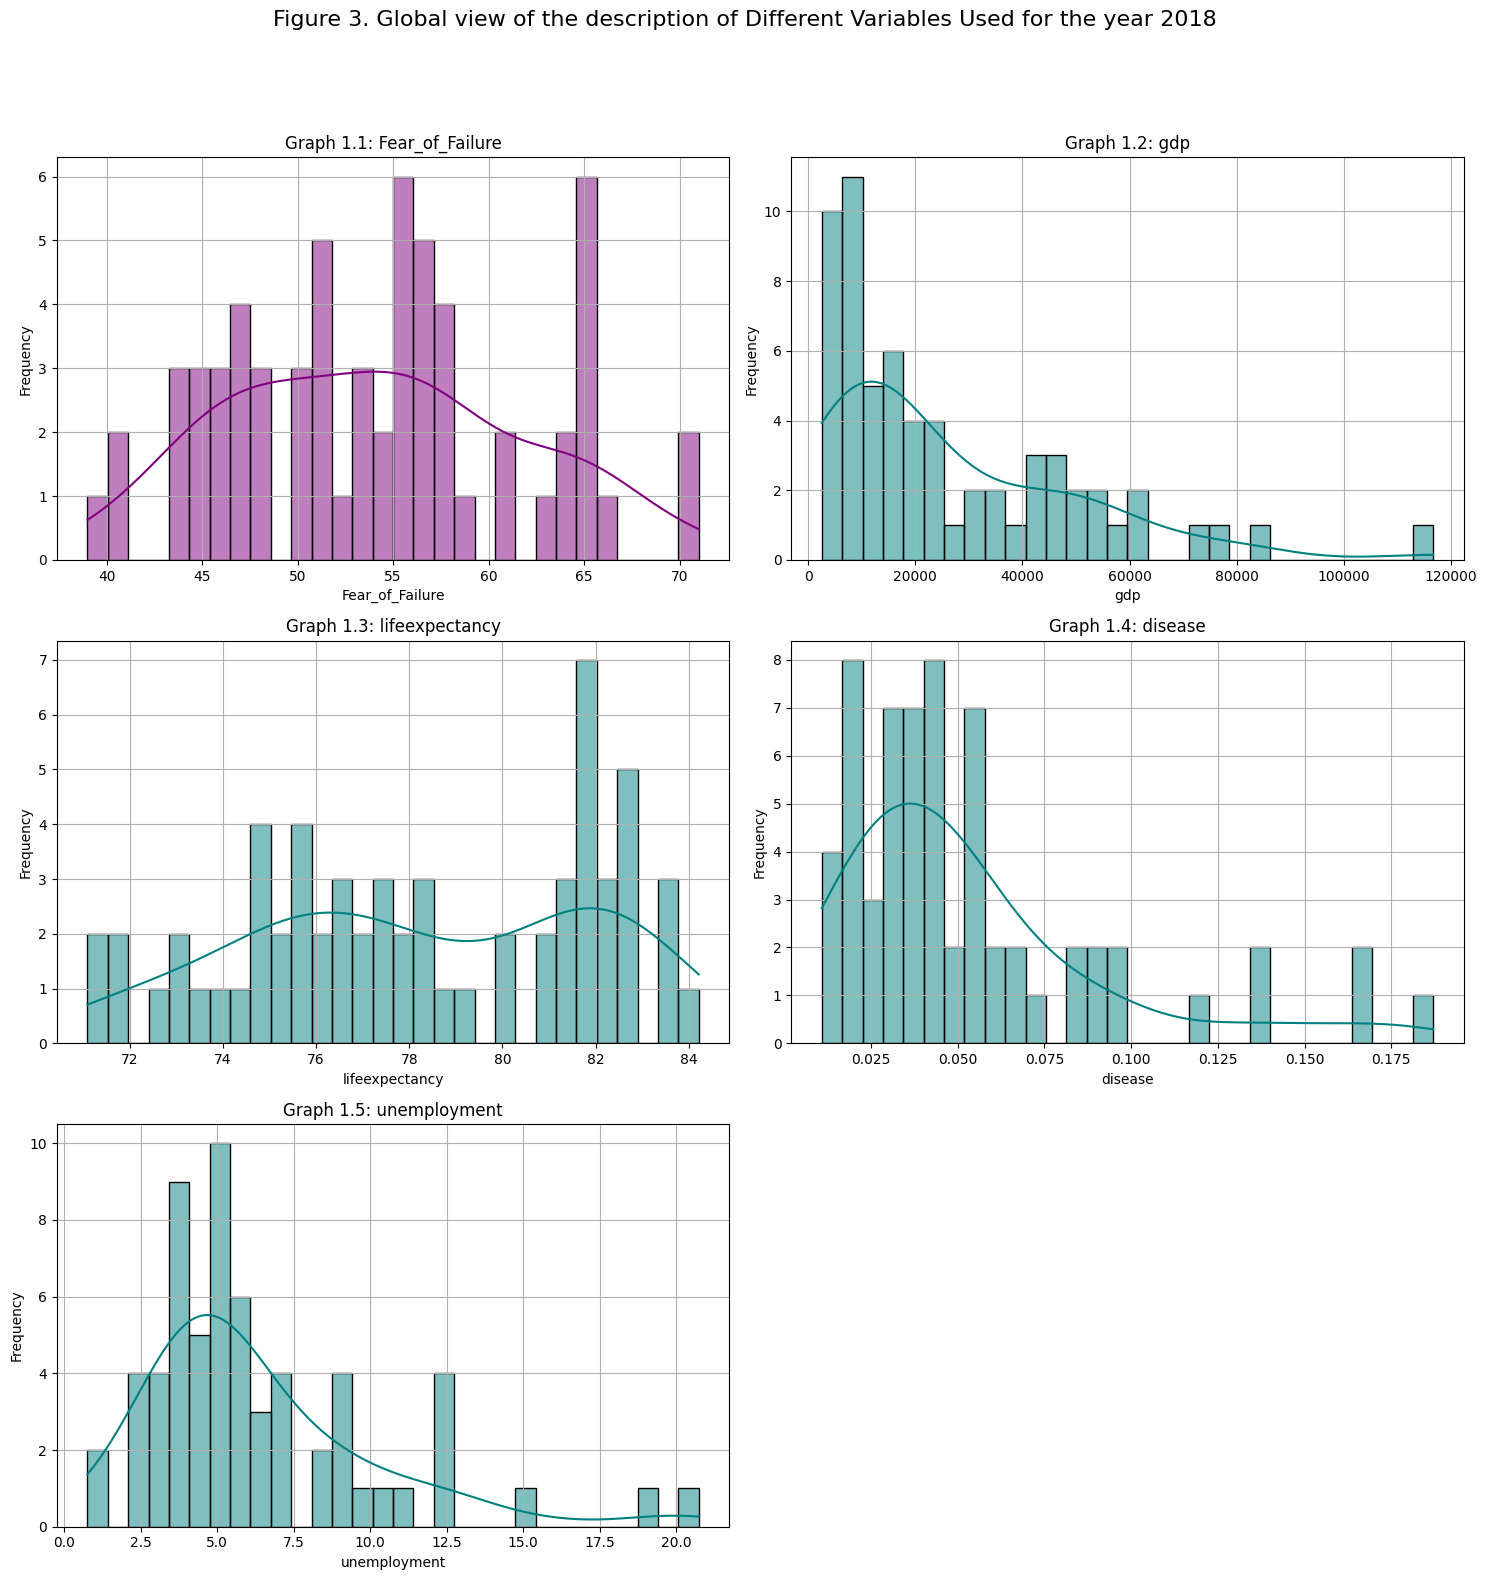

In [ ]:
# List of columns you're interested in
columns_to_plot = ['Fear_of_Failure', 'gdp', 'lifeexpectancy', 'disease', 'unemployment']  # Added 'unemployment'

# Number of columns in the grid
n_cols = 2
n_rows = (len(columns_to_plot) // n_cols) + (1 if len(columns_to_plot) % n_cols > 0 else 0)

# Create the figure and grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Set the panel title
fig.suptitle('Figure 3. Global view of the description of Different Variables Used for the year 2018', fontsize=16, y=1.05)

# Create plots for each variable with different colors for 'Fear_of_Failure' and others
for i, column in enumerate(columns_to_plot):
    # Set color based on the column
    if column == 'Fear_of_Failure':
        color = 'purple'  # Color for 'Fear_of_Failure'
    else:
        color = 'teal'  # Color for other variables

    sns.histplot(df2_filtered[column], kde=True, bins=30, color=color, ax=axes[i])
    axes[i].set_title(f'Graph 1.{i+1}: {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)

# Remove empty axes if needed
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()
plt.show()


## V. b) Bivariate Representation

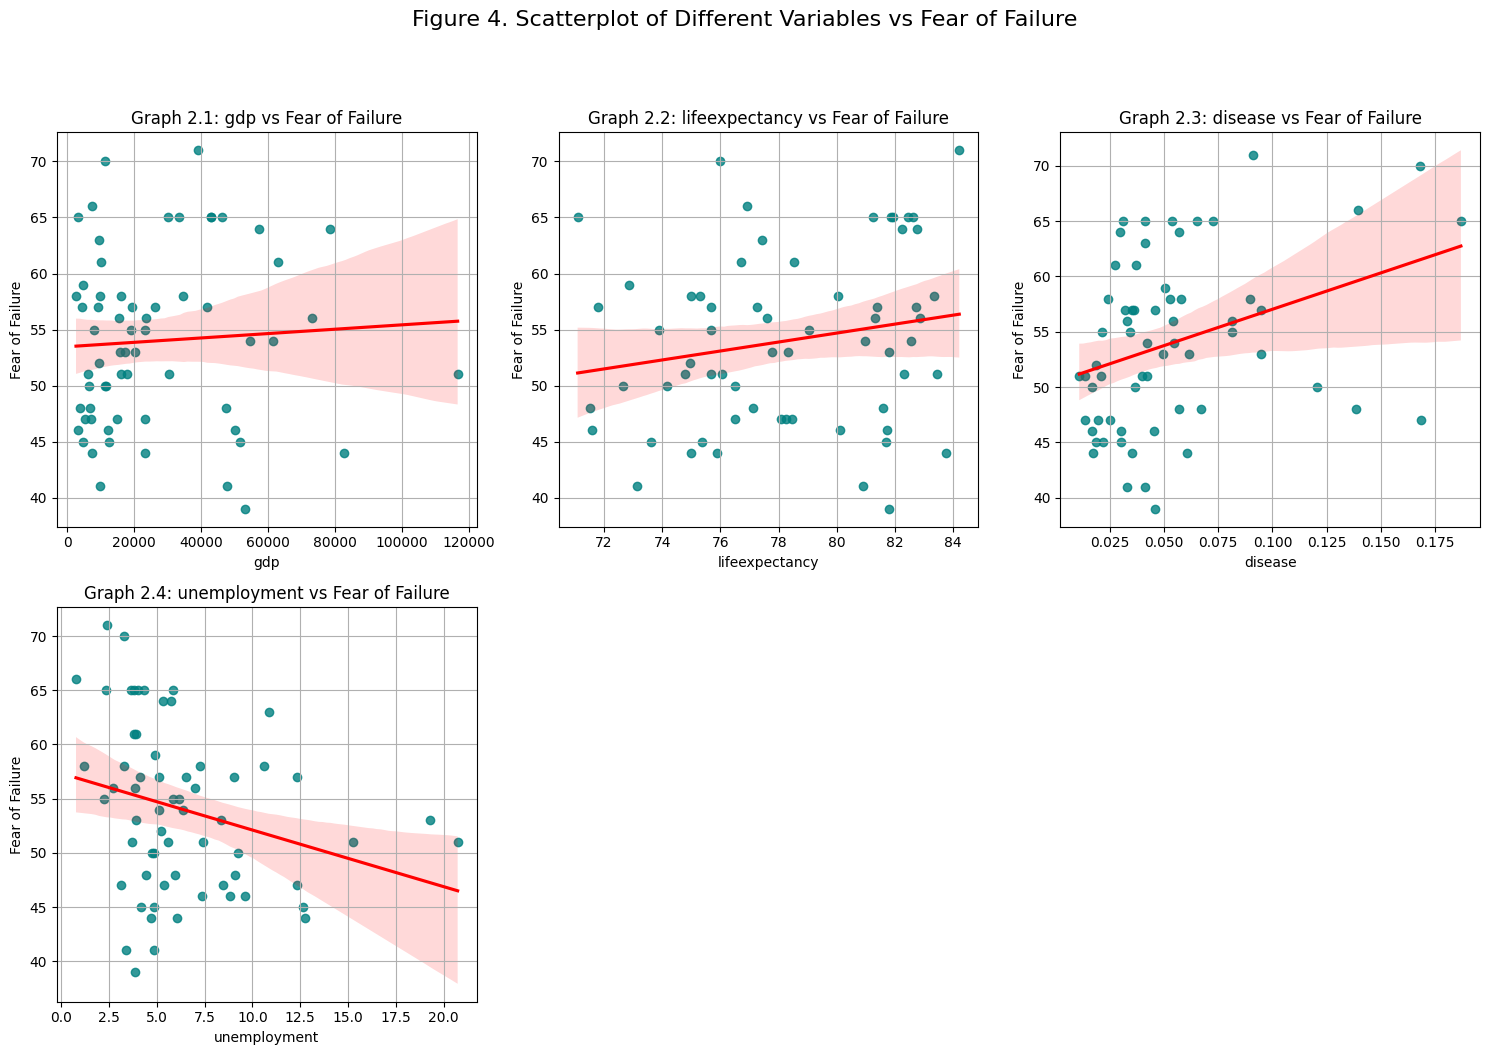

In [ ]:
# List of columns you're interested in, excluding 'Fear_of_Failure'
columns_to_plot = ['gdp', 'lifeexpectancy', 'disease', 'unemployment']  # Added 'unemployment'

# Number of columns in the grid (adjust based on the number of variables)
n_cols = 3  # You can adjust this to any number you like
n_rows = (len(columns_to_plot) // n_cols) + (1 if len(columns_to_plot) % n_cols > 0 else 0)

# Create the figure and grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Set the panel title
fig.suptitle('Figure 4. Scatterplot of Different Variables vs Fear of Failure', fontsize=16, y=1.05)

# Create regression plots for each variable with 'Fear_of_Failure', including 'unemployment'
for i, column in enumerate(columns_to_plot):
    sns.regplot(x=df2_filtered[column], y=df2_filtered['Fear_of_Failure'], ax=axes[i], scatter_kws={'color': 'teal'}, line_kws={'color': 'red'})
    axes[i].set_title(f'Graph 2.{i+1}: {column} vs Fear of Failure')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Fear of Failure')
    axes[i].grid(True)

# Remove empty axes if needed
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Fit the model using OLS regression
model = smf.ols(formula="Fear_of_Failure ~ gdp + lifeexpectancy + disease + unemployment", data=df2_filtered).fit()

# Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        Fear_of_Failure   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     4.441
Date:                Wed, 15 Jan 2025   Prob (F-statistic):            0.00337
Time:                        12:15:00   Log-Likelihood:                -208.80
No. Observations:                  63   AIC:                             427.6
Df Residuals:                      58   BIC:                             438.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -15.9675     27.273     -0.

# VI. Results

Living in a country with a higher GDP does increase your fear of failure (see **Figure 4. Graph 2.1.**). However, this difference is not significant ($coef = 2.39e-05$, $p = 0.696$ >> 0.05).

Moreover, living in a country with an higher life expectancy does increase your fear of failure (see **Figure 4. Graph 2.2.**). However, this difference is not significant. ($coef = 0.53$, $p = 0.146$ >> 0.05).

In addition, living in a country with more disease threats does increase your fear of failure (see **Figure 4. Graph 2.3.**)). This difference is significant ($coef = 90.07$, $p = 0.000...1$ << 0.05)

Moreover, living in a country with an higher number of unemployment does decrease your fear of failure (see **Figure 4. Graph 2.4.**). However, this difference is not significant. ($coef = -0.47$, $p = 0.070$ > 0.05).

# VII. Conclusion

Our first two predictions and our last prediction, namely that higher GDP per capita is associated with lower levels of fear of failure, that greater life expectancy is linked to lower levels of fear of failure and that th emore the number of unemployment, the greater fear of failure, do not appear to significantly influence fear of failure. However, our last prediction was correct, as higher disease threat significantly increases the fear of failure, supporting the hypothesis that environmental factors related to health and safety may influence individuals' perceptions of failure.